# Nulling CDF Simulation


In [1]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2
from sionna.rt import load_scene

import SceneConfigSionna2
import nulling_cdf_utils as ncu

importlib.reload(SceneConfigSionna2)
importlib.reload(ncu)

from SceneConfigSionna2 import SceneConfigSionna
from nulling_cdf_utils import (
    plot_ieee_single_column_cdf,
    run_nulling_cdf_experiment,
    save_experiment_metrics,
)


In [2]:
scene = load_scene("blender_scene_big/10km_times_10km/10km_times_10km.xml")
SceneConfig = SceneConfigSionna(scene)
SceneConfig.build_coverage_map(grid_size=10, show_xy=True, plot=False)


x range: [-5024.417, 5015.583]
y range: [-5047.131, 5042.869]


## Simulation Parameters


In [3]:
# Geometry and deployment
ntn_rx = 200
tn_rx = 100
bs_row = 3
bs_col = 3
nbs = bs_row * bs_col
nsect = 3

# Satellite direction used by compute_positions in every macro simulation
azimuth = float(np.random.uniform(0.0, 360.0))
elevation = float(np.random.uniform(35.0, 90.0))

# Carrier and array configuration
fc = 9.99e9
tx_antenna_rows = 8
tx_antenna_cols = 8
tn_rx_antenna_rows = 1
tn_rx_antenna_cols = 1
tx_antennas = tx_antenna_rows * tx_antenna_cols

# TX sector orientation
# Sionna orientation order: [yaw, pitch, roll]
tx_sector_yaw_offset_deg = 0.0
tx_head_down_deg = 5.0
tx_sector_roll_deg = 0.0

tx_sector_yaw_offset_rad = np.deg2rad(tx_sector_yaw_offset_deg)
tx_sector_pitch_rad = -np.deg2rad(tx_head_down_deg)
tx_sector_roll_rad = np.deg2rad(tx_sector_roll_deg)

# Monte Carlo setting
num_macro_sims = 2
show_progress = True
plot_layout_on_first_sim = False

print(
    f"TX sector orientation: yaw_offset={tx_sector_yaw_offset_deg:.1f} deg, "
    f"head_down={tx_head_down_deg:.1f} deg, roll={tx_sector_roll_deg:.1f} deg"
)
print(f"Satellite azimuth={azimuth:.2f} deg, elevation={elevation:.2f} deg")


TX sector orientation: yaw_offset=0.0 deg, head_down=5.0 deg, roll=0.0 deg
Satellite azimuth=90.54 deg, elevation=69.85 deg


In [4]:
# Noise, thresholds, and MUSIC setup
EkT = -174
B = 100e6
Tx_power_dbm = 30
Tx_power = 10 ** ((Tx_power_dbm - 30) / 10)
Tx_power_handheld_dbm = 23
Tx_power_handheld = 10 ** ((Tx_power_handheld_dbm - 30) / 10)

NF = 7
NF_vsat = 3
NF_bs = 2
N0_dBm = EkT + 10 * np.log10(B) + NF
N0 = 10 ** ((N0_dBm - 30) / 10)
N0_vsat = 10 ** ((EkT + 10 * np.log10(B) + NF_vsat - 30) / 10)
N0_bs = 10 ** ((EkT + 10 * np.log10(B) + NF_bs - 30) / 10)

preamble_time = 20e-6
N0_sigma = N0_vsat / Tx_power / preamble_time
N0_sigma_handheld = 10 ** ((EkT + NF_bs - 30) / 10) / Tx_power_handheld / preamble_time

lambda_ranges = [0, 1e10, 1e11, 1e12]

snr_threshold = -6
inr_threshold = -6
h_ntn_th = np.sqrt(10 ** (inr_threshold / 10) * N0_bs * tx_antennas / Tx_power)
h_tn_th = np.sqrt(10 ** (snr_threshold / 10) * N0_bs * tx_antennas / Tx_power)
threshold_peft_db = 10 * np.log10(np.abs(h_tn_th) ** 2)
p_fa = 1 / B
pfa_threshold = chi2.ppf(1 - p_fa, 2 * tx_antennas) / 2
h_ntn_pfa_th = np.sqrt(pfa_threshold * N0_sigma)
h_tn_pfa_th = np.sqrt(pfa_threshold * N0_sigma_handheld)
threshold_ntn_pfa_db = 10 * np.log10(np.abs(h_ntn_pfa_th) ** 2)
threshold_tn_pfa_db = 10 * np.log10(np.abs(h_tn_pfa_th) ** 2)

music_num_sources = None
music_threshold = 3.0
music_covariance_mode = "sample"
music_num_snapshots = 100
music_noise_var = N0_bs / Tx_power
music_rng_seed = 7
music_source_estimation = "mdl"
music_energy_ratio = 0.95
music_reduce_ntn_ant = "max"
music_user_powers = None
music_use_sector_orientation = True
music_sector_pitch_rad = float(tx_sector_pitch_rad)
music_sector_roll_rad = float(tx_sector_roll_rad)
music_rotation_order = "zyx"
music_std_channel_mode = "conj"
music_std_manifold_label = "yz:+1"
music_std_flatten_order = "F"
music_std_scan_mode = "complex"
music_std_phi_offset_deg = 0.0
music_std_phi_mirror_about_sector = False
music_std_horizontal_sign = -1
music_sector_forward_only = True
music_sector_forward_cos_min = 0.0
music_phi_grid_deg = np.arange(0.0, 360.0, 1.0)
music_theta_grid_deg = np.arange(0.0, 181.0, 1.0)

print(f"h_tn_th = {h_tn_th:.4e}")
print(f"h_ntn_th = {h_ntn_th:.4e}")
print(f"TN Pfa threshold = {threshold_tn_pfa_db:.2f} dB")
print(f"NTN Pfa threshold = {threshold_ntn_pfa_db:.2f} dB")
print(f"Beamforming threshold = {threshold_peft_db:.2f} dB")


h_tn_th = 3.1849e-06
h_ntn_th = 3.1849e-06
TN Pfa threshold = -127.24 dB
NTN Pfa threshold = -53.24 dB
Beamforming threshold = -109.94 dB


## Monte Carlo Experiment

- Each macro simulation calls `compute_positions(...)` and `compute_paths(...)`.
- BS locations remain fixed because the same grid deployment is used in every macro simulation.
- TN users are paired to the strongest valid TX over all BS sectors.
- If the minimum number of paired TN users across all TX sectors is `m`, each macro simulation runs exactly `m` small rounds.
- In each small round, every TX serves one paired TN and nulls all NTN users detected by MUSIC for that TX.
- INR is computed as the sum of interference powers from all TX beams over the noise power.


In [5]:
result_dir = Path("result")
result_dir.mkdir(parents=True, exist_ok=True)

compute_positions_kwargs_mc = dict(
    ntn_rx=ntn_rx,
    tn_rx=tn_rx,
    azimuth=azimuth,
    elevation=elevation,
    centerBS=False,
    bs_grid=(bs_row, bs_col),
    bs_boundary=1500,
    tn_building_ratio= 0.6,
    tn_distance=400,
    ntn_building_ratio=0.6,
    plot_grid=plot_layout_on_first_sim,
    plot_bs=plot_layout_on_first_sim,
    plot_tn=plot_layout_on_first_sim,
    plot_ntn=plot_layout_on_first_sim,
)

compute_paths_kwargs_mc = dict(
    nsect=nsect,
    fc=fc,
    tx_rows=tx_antenna_rows,
    tx_cols=tx_antenna_cols,
    tn_rx_rows=tn_rx_antenna_rows,
    tn_rx_cols=tn_rx_antenna_cols,
    max_depth=0,
    bandwidth=B,
    tx_power_dbm=Tx_power_dbm,
    sector_yaw_offset_rad=tx_sector_yaw_offset_rad,
    sector_pitch_rad=tx_sector_pitch_rad,
    sector_roll_rad=tx_sector_roll_rad,
)

music_kwargs_mc = dict(
    tx_rows=int(tx_antenna_rows),
    tx_cols=int(tx_antenna_cols),
    nsect=int(nsect),
    pair_keys=None,
    detect_num_sources=music_num_sources,
    detect_threshold=music_threshold,
    detect_user_powers=music_user_powers,
    detect_noise_var=music_noise_var,
    detect_covariance_mode=music_covariance_mode,
    detect_num_snapshots=music_num_snapshots,
    detect_rng_seed=music_rng_seed,
    detect_source_estimation=music_source_estimation,
    detect_energy_ratio=music_energy_ratio,
    detect_reduce_rx_ant=music_reduce_ntn_ant,
    channel_mode=music_std_channel_mode,
    manifold_label=music_std_manifold_label,
    flatten_order=music_std_flatten_order,
    scan_mode=music_std_scan_mode,
    phi_offset_deg=music_std_phi_offset_deg,
    phi_mirror_about_sector=music_std_phi_mirror_about_sector,
    steering_horizontal_sign=music_std_horizontal_sign,
    use_sector_orientation=music_use_sector_orientation,
    sector_pitch_rad=music_sector_pitch_rad,
    sector_roll_rad=music_sector_roll_rad,
    rotation_order=music_rotation_order,
    sector_forward_only=music_sector_forward_only,
    sector_forward_cos_min=music_sector_forward_cos_min,
    phi_grid_deg=music_phi_grid_deg,
    theta_grid_deg=music_theta_grid_deg,
)

nulling_cdf_results = run_nulling_cdf_experiment(
    SceneConfig,
    num_macro_sims=num_macro_sims,
    compute_positions_kwargs=compute_positions_kwargs_mc,
    compute_paths_kwargs=compute_paths_kwargs_mc,
    lambda_ranges=lambda_ranges,
    h_tn_th=h_tn_th,
    tx_antennas=tx_antennas,
    tx_power=Tx_power,
    noise_power=N0,
    music_kwargs=music_kwargs_mc,
    plot_first_sim_only=plot_layout_on_first_sim,
    show_progress=show_progress,
)

metrics_path = save_experiment_metrics(
    nulling_cdf_results,
    result_dir=result_dir,
    output_name="nulling_cdf_metrics.npz",
)

macro_stats = nulling_cdf_results["macro_stats"]
macro_min_count = np.asarray([row["min_count"] for row in macro_stats], dtype=int)
macro_detected_ntn = np.asarray([row["detected_ntn_count"] for row in macro_stats], dtype=int)
macro_interfered_ntn = np.asarray([row["interfered_ntn_count"] for row in macro_stats], dtype=int)

print(f"Number of macro simulations: {num_macro_sims}")
print(f"Macro simulations with min_count > 0: {np.count_nonzero(macro_min_count > 0)}")
print(f"Average min_count: {macro_min_count.mean() if macro_min_count.size else 0:.2f}")
print(f"Average detected NTN count: {macro_detected_ntn.mean() if macro_detected_ntn.size else 0:.2f}")
print(f"Average interfered NTN count: {macro_interfered_ntn.mean() if macro_interfered_ntn.size else 0:.2f}")
print(f"Raw INR samples: {nulling_cdf_results['raw_inr_db'].size}")
print(f"Raw SNR samples: {nulling_cdf_results['raw_snr_db'].size}")
for lambda_ in lambda_ranges:
    print(
        f"lambda={lambda_:.0e}: "
        f"INR samples={nulling_cdf_results['null_inr_db'][float(lambda_)].size}, "
        f"SNR samples={nulling_cdf_results['null_snr_db'][float(lambda_)].size}"
    )
print(f"Metrics saved to: {metrics_path}")


Monte Carlo:   0%|          | 0/2 [00:00<?, ?it/s]

Number of macro simulations: 2
Macro simulations with min_count > 0: 0
Average min_count: 0.00
Average detected NTN count: 139.00
Average interfered NTN count: 184.00
Raw INR samples: 0
Raw SNR samples: 0
lambda=0e+00: INR samples=0, SNR samples=0
lambda=1e+10: INR samples=0, SNR samples=0
lambda=1e+11: INR samples=0, SNR samples=0
lambda=1e+12: INR samples=0, SNR samples=0
Metrics saved to: result/nulling_cdf_metrics.npz


/workspace/shizhen/NTN-NULLING-NONCOH/nulling_cdf_utils.py:456: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower right", frameon=True)


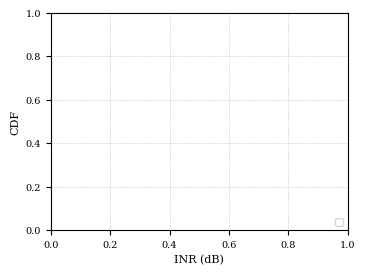

INR CDF PNG: result/nulling_inr_cdf.png
INR CDF PDF: result/nulling_inr_cdf.pdf


In [6]:
inr_cdf_plot = plot_ieee_single_column_cdf(
    nulling_cdf_results["raw_inr_db"],
    nulling_cdf_results["null_inr_db"],
    xlabel="INR (dB)",
    output_stem="nulling_inr_cdf",
    result_dir=result_dir,
)
plt.show()
print(f"INR CDF PNG: {inr_cdf_plot['png_path']}")
print(f"INR CDF PDF: {inr_cdf_plot['pdf_path']}")


/workspace/shizhen/NTN-NULLING-NONCOH/nulling_cdf_utils.py:456: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower right", frameon=True)


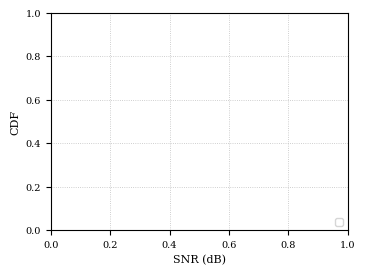

SNR CDF PNG: result/nulling_snr_cdf.png
SNR CDF PDF: result/nulling_snr_cdf.pdf


In [7]:
snr_cdf_plot = plot_ieee_single_column_cdf(
    nulling_cdf_results["raw_snr_db"],
    nulling_cdf_results["null_snr_db"],
    xlabel="SNR (dB)",
    output_stem="nulling_snr_cdf",
    result_dir=result_dir,
)
plt.show()
print(f"SNR CDF PNG: {snr_cdf_plot['png_path']}")
print(f"SNR CDF PDF: {snr_cdf_plot['pdf_path']}")


In [8]:
print("INR aggregation rule: total interference power from all TX beams divided by noise power.")
print("CDF figures are saved in IEEE single-column format.")


INR aggregation rule: total interference power from all TX beams divided by noise power.
CDF figures are saved in IEEE single-column format.
